# Cell 1 — Mount Drive + Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/dataset_drink_brand_logo.rar'
!apt-get install -qq unrar && unrar x "$path" /content/ > /dev/null

print("✅ Done!")

Mounted at /content/drive
✅ Done!


In [6]:
import os
# Dataset path
DATASET_PATH = "/content/dataset_drink_brand_logo/classification"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

print("Dataset loaded successfully!")
print(DATASET_PATH)

Dataset loaded successfully!
/content/dataset_drink_brand_logo/classification


# Cell 2 — Import library + Dataset statistics

In [7]:
import os
import cv2
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# List class
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes:", classes)
print("Number of classes:", len(classes))


# Image count function
def count_images(data_dir):
    data = []

    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        data.append([cls, count])
    return pd.DataFrame(data, columns=["Class", "Images"])


train_df = count_images(TRAIN_DIR)
val_df   = count_images(VAL_DIR)
test_df  = count_images(TEST_DIR)

# Merge statistics
summary_df = pd.DataFrame({
    "Class": train_df["Class"],
    "Train": train_df["Images"],
    "Validation": val_df["Images"],
    "Test": test_df["Images"]
})

summary_df["Total"] = (
    summary_df["Train"] +
    summary_df["Validation"] +
    summary_df["Test"]
)

display(summary_df)

print("\nTotal Images:", summary_df["Total"].sum())

Classes: ['7up', 'coca', 'fanta', 'pepsi', 'red_bull', 'sprite']
Number of classes: 6


,Class,Train,Validation,Test,Total
0,7up,918,196,198,1312
1,coca,2515,539,540,3594
2,fanta,1029,220,221,1470
3,pepsi,1679,359,361,2399
4,red_bull,840,180,180,1200
5,sprite,787,168,170,1125



Total Images: 11100


# Cell 3 — Visualization Dataset Distribution + Sample Images

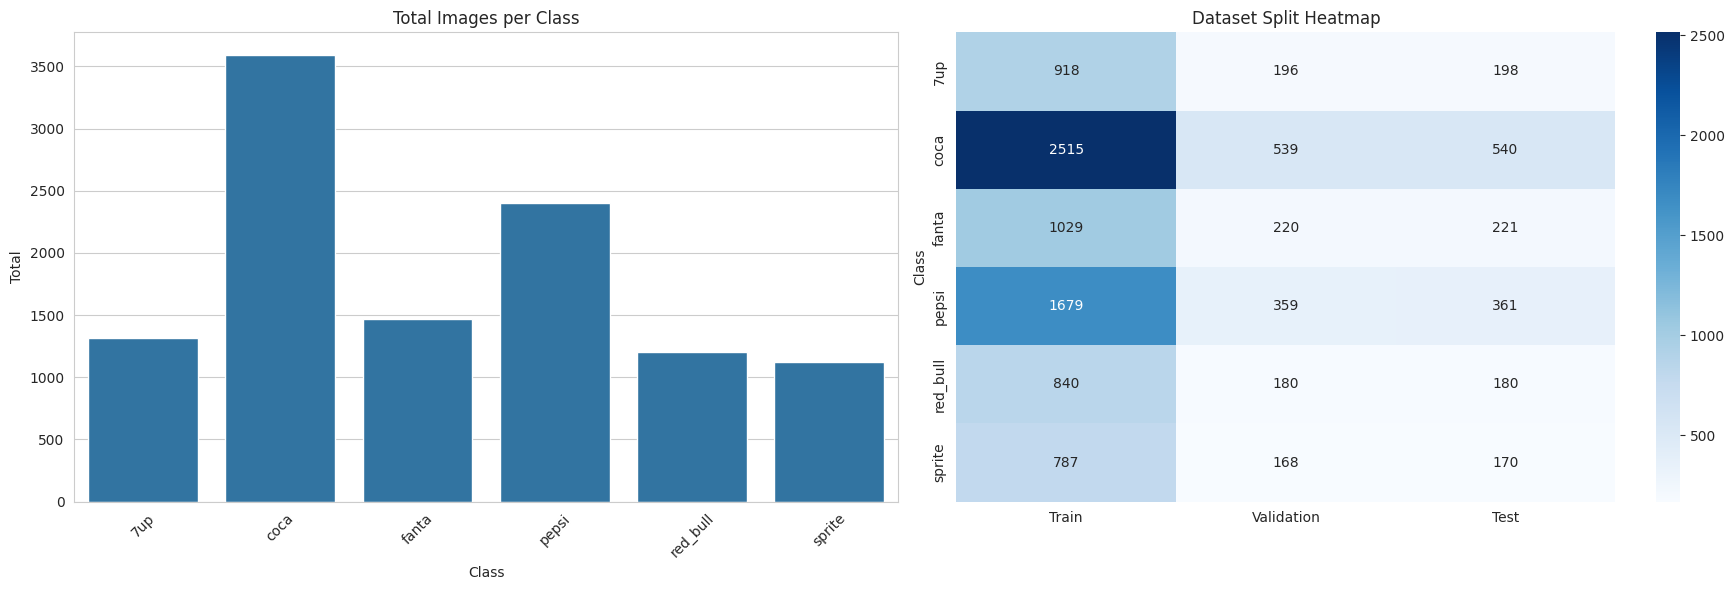

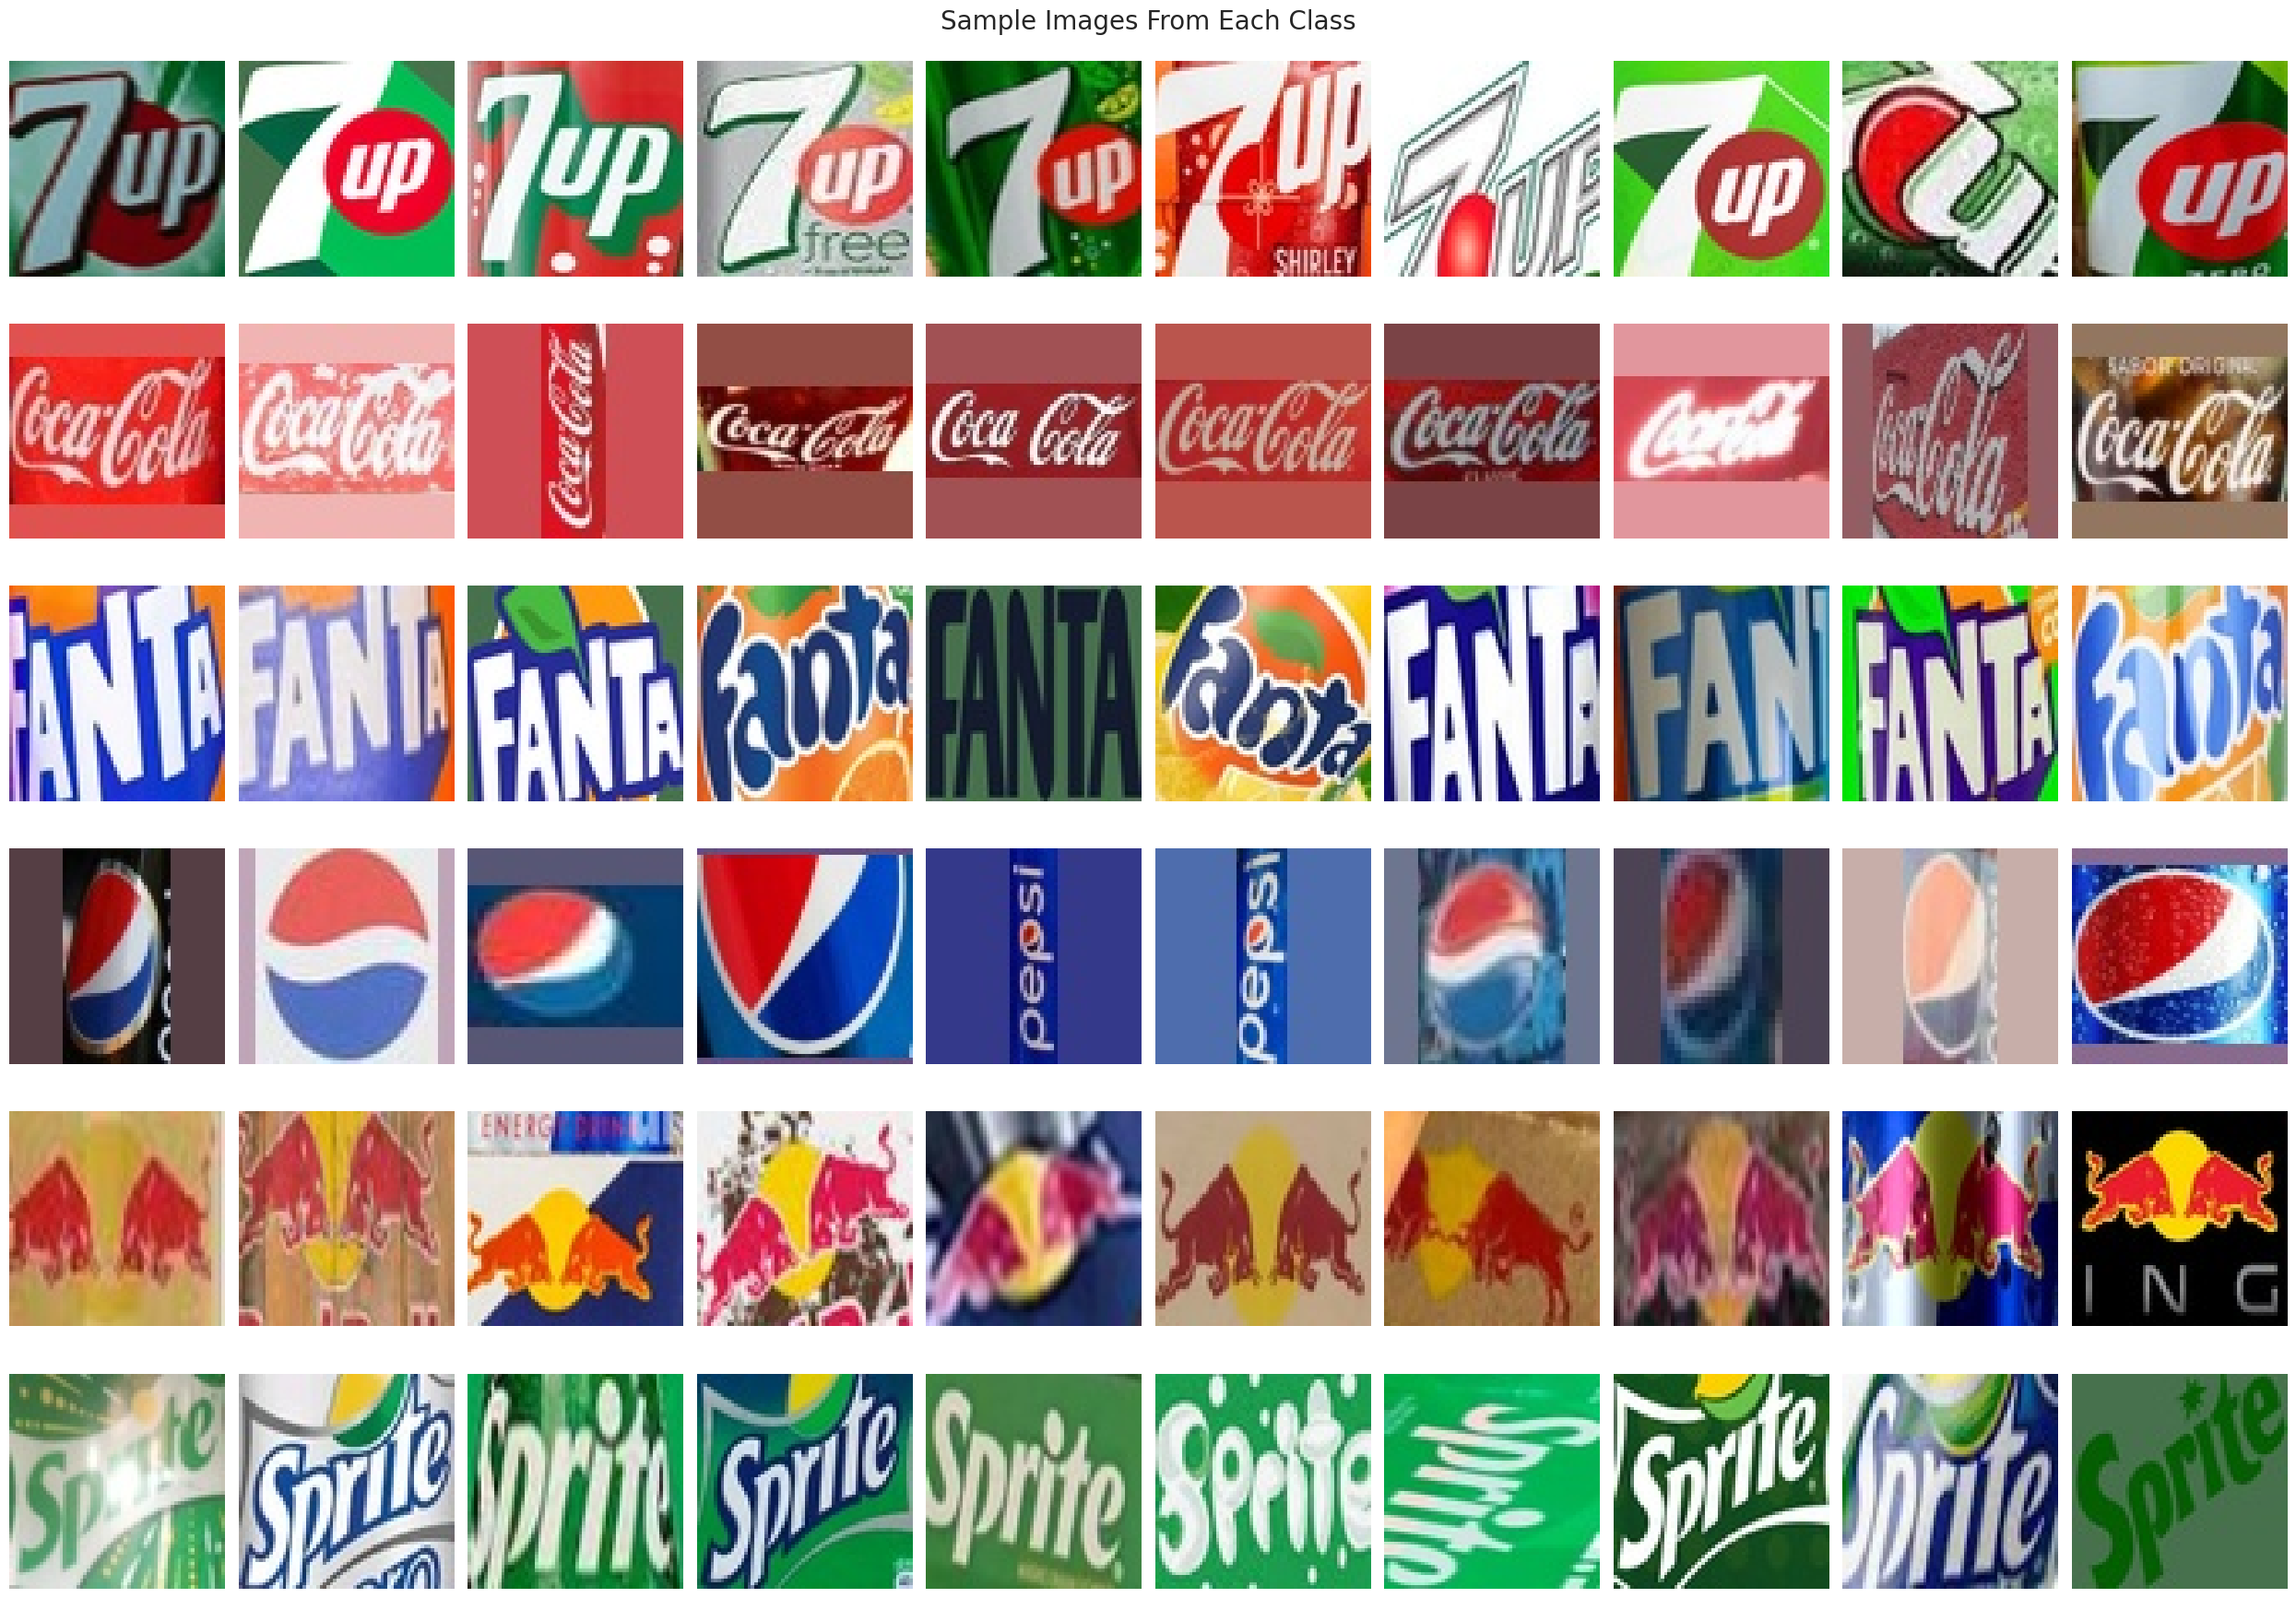

In [13]:
# =========================
# Dataset Distribution
# =========================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Tổng ảnh từng class
sns.barplot(
    x="Class",
    y="Total",
    data=summary_df,
    ax=axes[0]
)

axes[0].set_title("Total Images per Class")
axes[0].tick_params(axis='x', rotation=45)

# Heatmap train/val/test
heatmap_data = summary_df.set_index("Class")[["Train", "Validation", "Test"]]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)

axes[1].set_title("Dataset Split Heatmap")

plt.tight_layout()
plt.show()


# =========================
# Show Sample Images
# =========================

samples_per_class = 10

plt.figure(figsize=(25, len(classes) * 3))

plot_index = 1

for cls in classes:

    cls_path = os.path.join(TRAIN_DIR, cls)

    images = [
        img for img in os.listdir(cls_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ][:samples_per_class]

    for idx, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        plt.subplot(len(classes), samples_per_class, plot_index)
        plt.imshow(img)
        plt.axis("off")

        # Currently, a label is displayed for the first image in each row.
        if idx == 0:
            plt.ylabel(
                cls,
                fontsize=14,
                rotation=0,
                labelpad=40,
                weight='bold'
            )

        plot_index += 1

plt.suptitle("Sample Images From Each Class", fontsize=20)
plt.tight_layout()
plt.show()

# Cell 4 — In-depth image analysis (Size, Channel, Brightness)

100%|██████████| 6/6 [00:01<00:00,  5.53it/s]


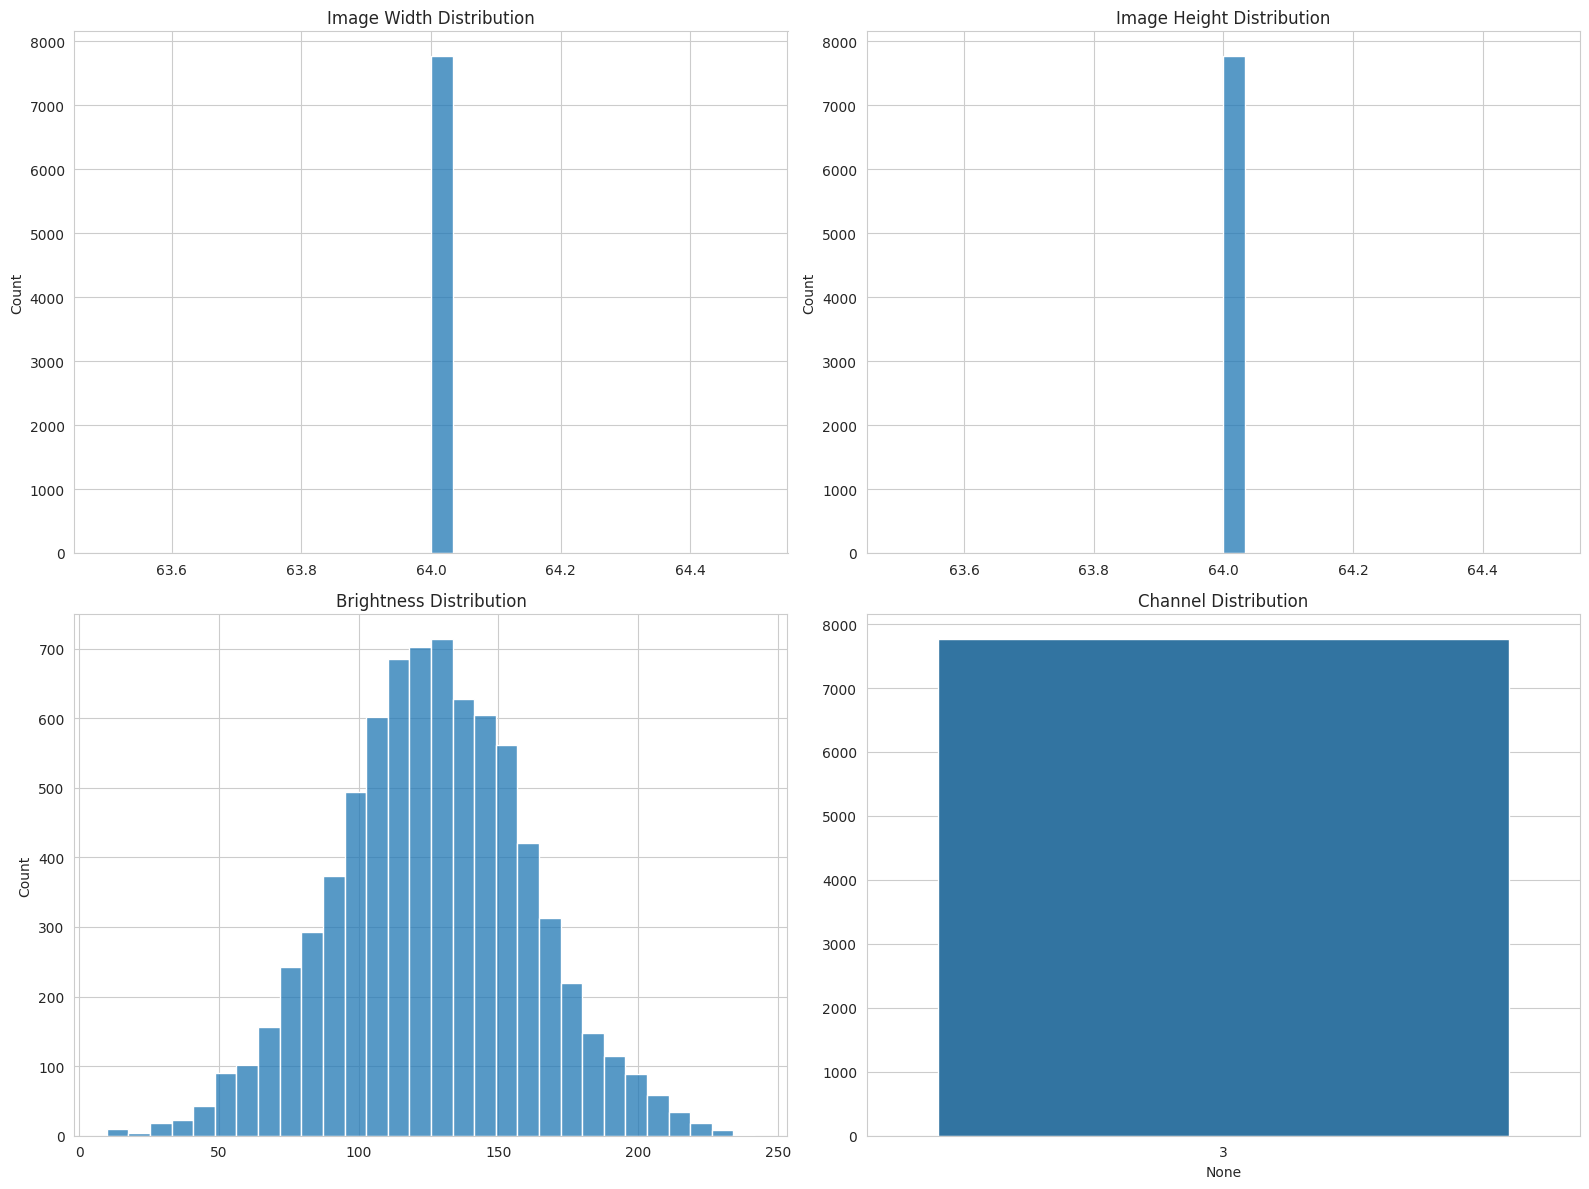

,Width,Height
count,7768.0,7768.0
mean,64.0,64.0
std,0.0,0.0
min,64.0,64.0
25%,64.0,64.0
50%,64.0,64.0
75%,64.0,64.0
max,64.0,64.0


In [9]:
image_widths = []
image_heights = []
channels = []
brightness_values = []

for cls in tqdm(classes):

    cls_path = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(cls_path):

        img_path = os.path.join(cls_path, img_name)

        try:
            img = cv2.imread(img_path)

            # Width - Height
            h, w = img.shape[:2]

            image_widths.append(w)
            image_heights.append(h)

            # Channels
            if len(img.shape) == 3:
                channels.append(img.shape[2])
            else:
                channels.append(1)

            # Brightness
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness_values.append(gray.mean())

        except:
            pass


# =========================
# Visualization
# =========================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Width Distribution
sns.histplot(image_widths, bins=30, ax=axes[0,0])
axes[0,0].set_title("Image Width Distribution")

# Height Distribution
sns.histplot(image_heights, bins=30, ax=axes[0,1])
axes[0,1].set_title("Image Height Distribution")

# Brightness Distribution
sns.histplot(brightness_values, bins=30, ax=axes[1,0])
axes[1,0].set_title("Brightness Distribution")

# Channels Distribution
channel_counts = pd.Series(channels).value_counts()

sns.barplot(
    x=channel_counts.index.astype(str),
    y=channel_counts.values,
    ax=axes[1,1]
)

axes[1,1].set_title("Channel Distribution")

plt.tight_layout()
plt.show()


# =========================
# Statistics
# =========================

size_df = pd.DataFrame({
    "Width": image_widths,
    "Height": image_heights
})

display(size_df.describe())

# Cell 5 — RGB Statistics + Dataset Summary

100%|██████████| 6/6 [00:05<00:00,  1.07it/s]


Dataset Mean : [0.5745321  0.46327622 0.45758863]
Dataset Std  : [0.21944414 0.20603594 0.20709541]


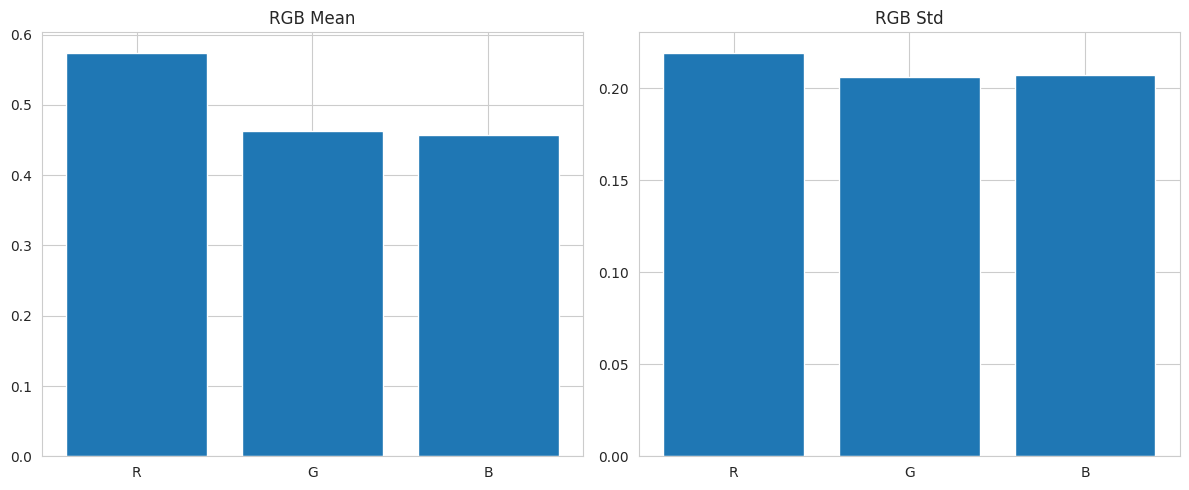

DATASET ANALYSIS SUMMARY
Classes                : ['7up', 'coca', 'fanta', 'pepsi', 'red_bull', 'sprite']
Number of classes      : 6
Total Images           : 11100

Train Images: 7768
Validation Images: 1662
Test Images: 1670

Image Width Mean : 64.0
Image Height Mean: 64.0

Brightness Mean : 126.45232965722757

Dataset Mean: [0.5745321  0.46327622 0.45758863]
Dataset Std : [0.21944414 0.20603594 0.20709541]


In [10]:
means = []
stds = []

for cls in tqdm(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img / 255.0
            means.append(img.mean(axis=(0,1)))
            stds.append(img.std(axis=(0,1)))
        except:
            pass


# Mean & Std
mean = np.mean(means, axis=0)
std  = np.mean(stds, axis=0)

print("Dataset Mean :", mean)
print("Dataset Std  :", std)


# =========================
# Visualization RGB
# =========================

channels_name = ["R", "G", "B"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(channels_name, mean)
axes[0].set_title("RGB Mean")

axes[1].bar(channels_name, std)
axes[1].set_title("RGB Std")

plt.tight_layout()
plt.show()


# =========================
# Final Summary
# =========================

print("="*60)
print("DATASET ANALYSIS SUMMARY")
print("="*60)

print(f"Classes                : {classes}")
print(f"Number of classes      : {len(classes)}")
print(f"Total Images           : {summary_df['Total'].sum()}")

print("\nTrain Images:", summary_df["Train"].sum())
print("Validation Images:", summary_df["Validation"].sum())
print("Test Images:", summary_df["Test"].sum())

print("\nImage Width Mean :", np.mean(image_widths))
print("Image Height Mean:", np.mean(image_heights))

print("\nBrightness Mean :", np.mean(brightness_values))

print("\nDataset Mean:", mean)
print("Dataset Std :", std)

print("="*60)